In [1]:
# Cell 0 — Setup
!pip install -q kagglehub timm
from google.colab import drive
from pathlib import Path
import json, os, gc, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import timm
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
KOA_ROOT = Path('/content/drive/MyDrive/KOA')
NB6_OUT = KOA_ROOT / 'NB6'
NB6_OUT.mkdir(parents=True, exist_ok=True)
SAVE_DIR = KOA_ROOT / 'saved_models'

import kagglehub
mendeley_path = kagglehub.dataset_download("tommyngx/digital-knee-xray")
mendeley_root = Path(mendeley_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

with open(str(KOA_ROOT / 'NB2' / 'nb2_results.json')) as f:
    nb2 = json.load(f)
with open(str(KOA_ROOT / 'NB3' / 'nb3_results.json')) as f:
    nb3 = json.load(f)
print("✓ Loaded NB2 + NB3 results")

Mounted at /content/drive
Using Colab cache for faster access to the 'digital-knee-xray' dataset.
Device: cuda
✓ Loaded NB2 + NB3 results


In [2]:
# Cell 1 — Mendeley External Dataset
IMG_SIZE = 224
SEEDS = [42, 123, 456]

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

grade_map = {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
ext_records = []
for d in mendeley_root.rglob('*'):
    if d.is_dir() and d.name == 'MedicalExpert-I':
        for grade_folder in sorted(d.iterdir()):
            if not grade_folder.is_dir():
                continue
            grade = grade_map.get(grade_folder.name, None)
            if grade is None:
                continue
            for f in grade_folder.glob('*'):
                if f.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                    ext_records.append({'path': str(f), 'grade': grade})

ext_df = pd.DataFrame(ext_records)
print(f"External images: {len(ext_df)}")
print(f"Distribution: {dict(ext_df['grade'].value_counts().sort_index())}")

class KneeDataset(Dataset):
    def __init__(self, df, transform, label_col='grade'):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row.path).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0,0,0))
        return self.transform(img), int(row[self.label_col])

ext_loader_5 = DataLoader(KneeDataset(ext_df, val_transform),
                           batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

External images: 1650
Distribution: {0: np.int64(514), 1: np.int64(477), 2: np.int64(232), 3: np.int64(221), 4: np.int64(206)}


In [3]:
# Cell 2 — External Validation: 5-Class
ARCHITECTURES = {
    'ConvNeXt-L': 'convnext_large',
    'EfficientNet-B0': 'efficientnet_b0',
    'DenseNet201': 'densenet201',
    'Xception': 'xception',
    'Swin-T': 'swin_tiny_patch4_window7_224',
}

ext_5class = {}
for arch_name, model_name in ARCHITECTURES.items():
    ext_5class[arch_name] = {}
    for loss_name in ['CE', 'CORAL']:
        accs = []
        for seed in SEEDS:
            model_path = str(SAVE_DIR / f"{arch_name}_{loss_name}_5class_seed{seed}.pth")
            if not os.path.exists(model_path):
                continue

            if loss_name == 'CORAL':
                class OrdinalModel(nn.Module):
                    def __init__(self, base_name, num_classes):
                        super().__init__()
                        self.backbone = timm.create_model(base_name, pretrained=False, num_classes=0)
                        self.classifier = nn.Linear(self.backbone.num_features, num_classes - 1)
                    def forward(self, x):
                        return self.classifier(self.backbone(x))
                model = OrdinalModel(model_name, 5).to(device)
            else:
                model = timm.create_model(model_name, pretrained=False, num_classes=5).to(device)

            model.load_state_dict(torch.load(model_path, map_location=device))
            model.eval()

            all_preds, all_labels = [], []
            with torch.no_grad():
                for x, y in ext_loader_5:
                    x = x.to(device)
                    out = model(x)
                    if loss_name == 'CORAL':
                        pred = (torch.sigmoid(out) > 0.5).sum(dim=1).long()
                    else:
                        pred = torch.argmax(out, dim=1)
                    all_preds.extend(pred.cpu().numpy())
                    all_labels.extend(y.numpy())

            acc = accuracy_score(all_labels, all_preds)
            accs.append(acc)
            del model
            torch.cuda.empty_cache()

        ext_5class[arch_name][loss_name] = accs
        if accs:
            print(f"{arch_name} {loss_name}: ext_acc = {np.mean(accs):.4f} ± {np.std(accs):.4f}")

ext_5class_df = []
for arch in ARCHITECTURES:
    for loss in ['CE', 'CORAL']:
        vals = ext_5class.get(arch, {}).get(loss, [])
        if vals:
            ext_5class_df.append({'Architecture': arch, 'Loss': loss,
                                   'External Acc': f"{np.mean(vals):.3f}±{np.std(vals):.3f}"})
df_ext5 = pd.DataFrame(ext_5class_df)
print("\n" + df_ext5.to_string(index=False))
df_ext5.to_csv(str(NB6_OUT / 'nb6_ext_5class.csv'), index=False)
print("✓ nb6_ext_5class.csv")

ConvNeXt-L CE: ext_acc = 0.3257 ± 0.0085
ConvNeXt-L CORAL: ext_acc = 0.2473 ± 0.0203
EfficientNet-B0 CE: ext_acc = 0.2541 ± 0.0192
EfficientNet-B0 CORAL: ext_acc = 0.1952 ± 0.0054
DenseNet201 CE: ext_acc = 0.2644 ± 0.0155
DenseNet201 CORAL: ext_acc = 0.2115 ± 0.0211
Xception CE: ext_acc = 0.2277 ± 0.0008
Xception CORAL: ext_acc = 0.2131 ± 0.0176
Swin-T CE: ext_acc = 0.2697 ± 0.0120
Swin-T CORAL: ext_acc = 0.2129 ± 0.0051

   Architecture  Loss External Acc
     ConvNeXt-L    CE  0.326±0.009
     ConvNeXt-L CORAL  0.247±0.020
EfficientNet-B0    CE  0.254±0.019
EfficientNet-B0 CORAL  0.195±0.005
    DenseNet201    CE  0.264±0.016
    DenseNet201 CORAL  0.212±0.021
       Xception    CE  0.228±0.001
       Xception CORAL  0.213±0.018
         Swin-T    CE  0.270±0.012
         Swin-T CORAL  0.213±0.005
✓ nb6_ext_5class.csv


In [4]:
# Cell 3 — External Validation: Binary
BINARY_TASKS = {'Screening': 1, 'OA': 2, 'Severe': 3}
ext_binary = {}

for task_name, threshold in BINARY_TASKS.items():
    ext_df_bin = ext_df.copy()
    ext_df_bin['label'] = (ext_df_bin['grade'] >= threshold).astype(int)
    ext_loader_bin = DataLoader(KneeDataset(ext_df_bin, val_transform, label_col='label'),
                                 batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    ext_binary[task_name] = {}
    for arch_name, model_name in ARCHITECTURES.items():
        accs, aucs = [], []
        for seed in SEEDS:
            model_path = str(SAVE_DIR / f"{arch_name}_{task_name}_seed{seed}.pth")
            if not os.path.exists(model_path):
                continue
            model = timm.create_model(model_name, pretrained=False, num_classes=2).to(device)
            model.load_state_dict(torch.load(model_path, map_location=device))
            model.eval()

            all_preds, all_labels, all_probs = [], [], []
            with torch.no_grad():
                for x, y in ext_loader_bin:
                    x = x.to(device)
                    out = model(x)
                    prob = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
                    pred = torch.argmax(out, dim=1).cpu().numpy()
                    all_preds.extend(pred)
                    all_labels.extend(y.numpy())
                    all_probs.extend(prob)

            acc = accuracy_score(all_labels, all_preds)
            auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0
            accs.append(acc)
            aucs.append(auc)
            del model
            torch.cuda.empty_cache()

        ext_binary[task_name][arch_name] = {'acc': accs, 'auc': aucs}
        if accs:
            print(f"{task_name} {arch_name}: ext_acc={np.mean(accs):.4f} ext_auc={np.mean(aucs):.4f}")

ext_bin_rows = []
for task in BINARY_TASKS:
    for arch in ARCHITECTURES:
        d = ext_binary.get(task, {}).get(arch, {})
        if d.get('acc'):
            ext_bin_rows.append({'Task': task, 'Architecture': arch,
                                  'Ext Acc': f"{np.mean(d['acc']):.3f}±{np.std(d['acc']):.3f}",
                                  'Ext AUC': f"{np.mean(d['auc']):.3f}±{np.std(d['auc']):.3f}"})
df_ext_bin = pd.DataFrame(ext_bin_rows)
print("\n" + df_ext_bin.to_string(index=False))
df_ext_bin.to_csv(str(NB6_OUT / 'nb6_ext_binary.csv'), index=False)
print("✓ nb6_ext_binary.csv")

Screening ConvNeXt-L: ext_acc=0.7844 ext_auc=0.8925
Screening EfficientNet-B0: ext_acc=0.6877 ext_auc=0.6986
Screening DenseNet201: ext_acc=0.7214 ext_auc=0.8265
Screening Xception: ext_acc=0.7408 ext_auc=0.8429
Screening Swin-T: ext_acc=0.7515 ext_auc=0.8760
OA ConvNeXt-L: ext_acc=0.5851 ext_auc=0.8653
OA EfficientNet-B0: ext_acc=0.5067 ext_auc=0.6940
OA DenseNet201: ext_acc=0.4537 ext_auc=0.8072
OA Xception: ext_acc=0.4818 ext_auc=0.8144
OA Swin-T: ext_acc=0.5242 ext_auc=0.8422
Severe ConvNeXt-L: ext_acc=0.7667 ext_auc=0.9411
Severe EfficientNet-B0: ext_acc=0.5004 ext_auc=0.7481
Severe DenseNet201: ext_acc=0.6889 ext_auc=0.8872
Severe Xception: ext_acc=0.6772 ext_auc=0.8988
Severe Swin-T: ext_acc=0.7012 ext_auc=0.9440

     Task    Architecture     Ext Acc     Ext AUC
Screening      ConvNeXt-L 0.784±0.014 0.893±0.002
Screening EfficientNet-B0 0.688±0.037 0.699±0.062
Screening     DenseNet201 0.721±0.010 0.827±0.007
Screening        Xception 0.741±0.014 0.843±0.013
Screening          

Mean generalisation gap: 38.3pp ± 6.1pp


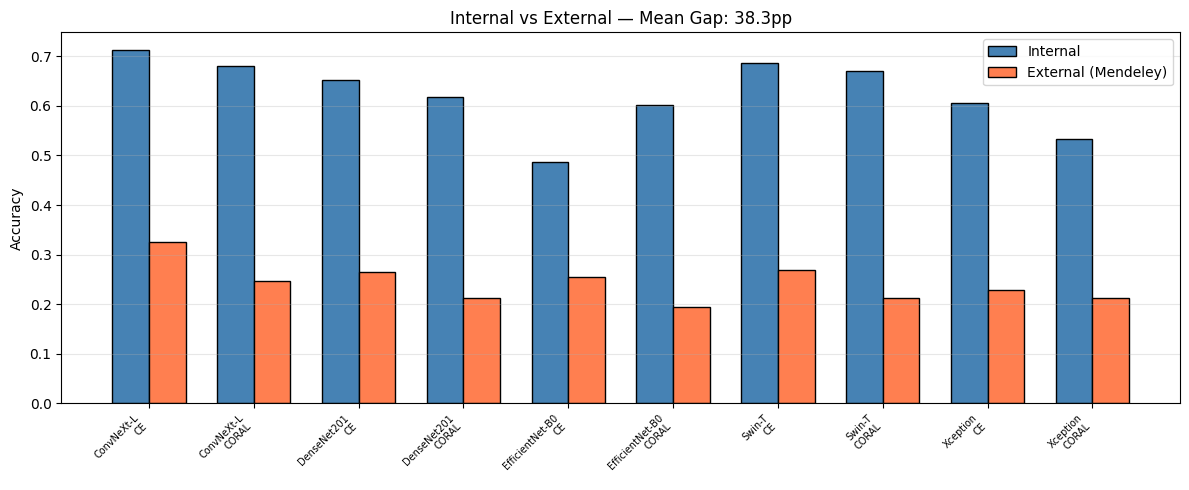

✓ nb6_gen_gap.png


In [5]:
# Cell 4 — Generalisation Gap
internal_accs = {}
for arch in ARCHITECTURES:
    for loss in ['CE', 'CORAL']:
        vals = nb2['results'].get(arch, {}).get(loss, {}).get('acc', [])
        if vals:
            internal_accs[f"{arch}_{loss}"] = np.mean(vals)

external_accs = {}
for arch in ARCHITECTURES:
    for loss in ['CE', 'CORAL']:
        vals = ext_5class.get(arch, {}).get(loss, [])
        if vals:
            external_accs[f"{arch}_{loss}"] = np.mean(vals)

common_keys = sorted(set(internal_accs.keys()) & set(external_accs.keys()))
gaps = [internal_accs[k] - external_accs[k] for k in common_keys]
print(f"Mean generalisation gap: {np.mean(gaps)*100:.1f}pp ± {np.std(gaps)*100:.1f}pp")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(common_keys))
w = 0.35
ax.bar(x - w/2, [internal_accs[k] for k in common_keys], w, label='Internal', color='steelblue', edgecolor='black')
ax.bar(x + w/2, [external_accs[k] for k in common_keys], w, label='External (Mendeley)', color='coral', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels([k.replace('_', '\n') for k in common_keys], fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title(f'Internal vs External — Mean Gap: {np.mean(gaps)*100:.1f}pp')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB6_OUT / 'nb6_gen_gap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb6_gen_gap.png")

In [6]:
# Cell 5 — Literature Comparison
lit = pd.DataFrame([
    {'Study': 'Tiulpin et al. (2019)', 'Dataset': 'MOST',
     'Task': '5-class KL', 'Metric': 'Accuracy', 'Reported': '66.7%',
     'DOI': '10.1038/s41598-018-37916-2'},
    {'Study': 'Chen et al. (2019)', 'Dataset': 'OAI',
     'Task': '5-class KL', 'Metric': 'Multi-class Acc', 'Reported': '71.6%',
     'DOI': '10.1016/j.compmedimag.2019.101720'},
    {'Study': 'Antony et al. (2017)', 'Dataset': 'OAI+MOST',
     'Task': '5-class KL', 'Metric': 'Accuracy', 'Reported': '57.6%',
     'DOI': '10.1109/ISBI.2017.7950743'},
    {'Study': 'Thomas et al. (2020)', 'Dataset': 'Kaggle',
     'Task': '5-class KL', 'Metric': 'Accuracy', 'Reported': '69.7%',
     'DOI': '10.1007/s10278-019-00305-2'},
    {'Study': 'Swiecicki et al. (2021)', 'Dataset': 'OAI',
     'Task': '5-class KL', 'Metric': 'Accuracy', 'Reported': '71.0%',
     'DOI': '10.1016/j.artmed.2021.102098'},
])

our_5class = nb2['best_accuracy']
our_best_binary = 0.0
for task in nb3.get('tasks', {}):
    for arch in nb3['tasks'][task]:
        accs = nb3['tasks'][task][arch].get('acc', [])
        if accs:
            our_best_binary = max(our_best_binary, np.mean(accs))

lit['Our Result'] = [f"{our_5class:.1%}"] * len(lit)
print(lit[['Study', 'Dataset', 'Task', 'Reported', 'Our Result', 'DOI']].to_string(index=False))
lit.to_csv(str(NB6_OUT / 'nb6_literature.csv'), index=False)
print("\n✓ nb6_literature.csv")

                  Study  Dataset       Task Reported Our Result                               DOI
  Tiulpin et al. (2019)     MOST 5-class KL    66.7%      71.6%        10.1038/s41598-018-37916-2
     Chen et al. (2019)      OAI 5-class KL    71.6%      71.6% 10.1016/j.compmedimag.2019.101720
   Antony et al. (2017) OAI+MOST 5-class KL    57.6%      71.6%         10.1109/ISBI.2017.7950743
   Thomas et al. (2020)   Kaggle 5-class KL    69.7%      71.6%        10.1007/s10278-019-00305-2
Swiecicki et al. (2021)      OAI 5-class KL    71.0%      71.6%      10.1016/j.artmed.2021.102098

✓ nb6_literature.csv


In [7]:
# Cell 6 — Hypothesis Testing
def ci95(vals):
    n = len(vals)
    if n < 3:
        return np.mean(vals), np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(n)
    h = se * stats.t.ppf(0.975, n - 1)
    m = np.mean(vals)
    return m - h, m + h

all_5class_accs = []
for arch in nb2['results']:
    for loss in nb2['results'][arch]:
        all_5class_accs.extend(nb2['results'][arch][loss]['acc'])

t1, p1 = stats.ttest_1samp(all_5class_accs, 0.75)
p1_one = p1 / 2 if t1 < 0 else 1 - p1 / 2
print(f"H1: 5-class ceiling < 0.75")
print(f"   t={t1:.3f}, p={p1_one:.6f} {'→ REJECT' if p1_one < 0.05 else '→ FAIL'}")

best_screen_accs = []
for arch in nb3.get('tasks', {}).get('Screening', {}):
    best_screen_accs.extend(nb3['tasks']['Screening'][arch].get('acc', []))
if best_screen_accs:
    t2, p2 = stats.ttest_1samp(best_screen_accs, 0.80)
    p2_one = 1 - p2 / 2 if t2 > 0 else p2 / 2
    print(f"\nH2: Screening (KL≥1) > 0.80")
    print(f"   t={t2:.3f}, p={p2_one:.6f} {'→ REJECT' if p2_one < 0.05 else '→ FAIL'}")

if gaps:
    t3, p3 = stats.ttest_1samp(gaps, 0)
    print(f"\nH3: External drop > 0")
    print(f"   Mean gap: {np.mean(gaps)*100:.1f}pp, t={t3:.3f}, p={p3/2:.6f}")

alpha_bonf = 0.05 / 3
print(f"\nBonferroni-corrected α = {alpha_bonf:.4f}")

H1: 5-class ceiling < 0.75
   t=-9.758, p=0.000000 → REJECT

H2: Screening (KL≥1) > 0.80
   t=-1.184, p=0.128085 → FAIL

H3: External drop > 0
   Mean gap: 38.3pp, t=18.819, p=0.000000

Bonferroni-corrected α = 0.0167


Tukey HSD — 5-class CE accuracy:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
     ConvNeXt-L     DenseNet201  -0.0604 0.0039 -0.1003 -0.0205   True
     ConvNeXt-L EfficientNet-B0  -0.2264    0.0 -0.2663 -0.1866   True
     ConvNeXt-L          Swin-T  -0.0262 0.2687  -0.066  0.0137  False
     ConvNeXt-L        Xception  -0.1077    0.0 -0.1476 -0.0678   True
    DenseNet201 EfficientNet-B0  -0.1661    0.0 -0.2059 -0.1262   True
    DenseNet201          Swin-T   0.0342 0.1026 -0.0057  0.0741  False
    DenseNet201        Xception  -0.0473 0.0193 -0.0872 -0.0074   True
EfficientNet-B0          Swin-T   0.2003    0.0  0.1604  0.2402   True
EfficientNet-B0        Xception   0.1188    0.0  0.0789  0.1586   True
         Swin-T        Xception  -0.0815 0.0004 -0.1214 -0.0416   True
--------------------------------------------

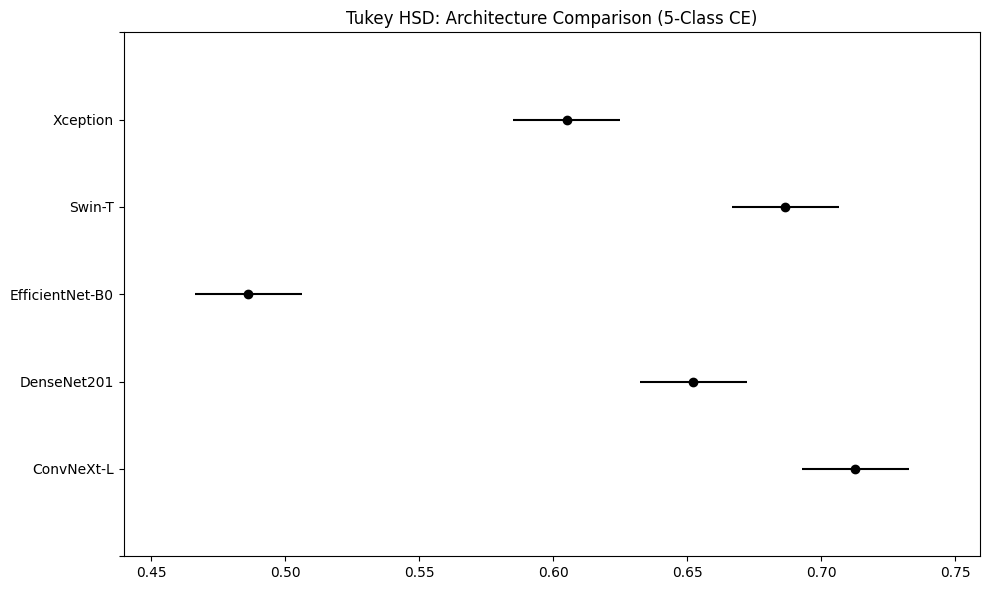

✓ nb6_tukey.png


In [8]:
# Cell 7 — Tukey HSD
ce_accs = []
ce_groups = []
for arch in nb2['results']:
    for acc in nb2['results'][arch].get('CE', {}).get('acc', []):
        ce_accs.append(acc)
        ce_groups.append(arch)

if ce_accs:
    tukey = pairwise_tukeyhsd(ce_accs, ce_groups, alpha=0.05)
    print("Tukey HSD — 5-class CE accuracy:")
    print(tukey)

    fig, ax = plt.subplots(figsize=(10, 6))
    tukey.plot_simultaneous(ax=ax)
    ax.set_title('Tukey HSD: Architecture Comparison (5-Class CE)')
    plt.tight_layout()
    fig.savefig(str(NB6_OUT / 'nb6_tukey.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ nb6_tukey.png")

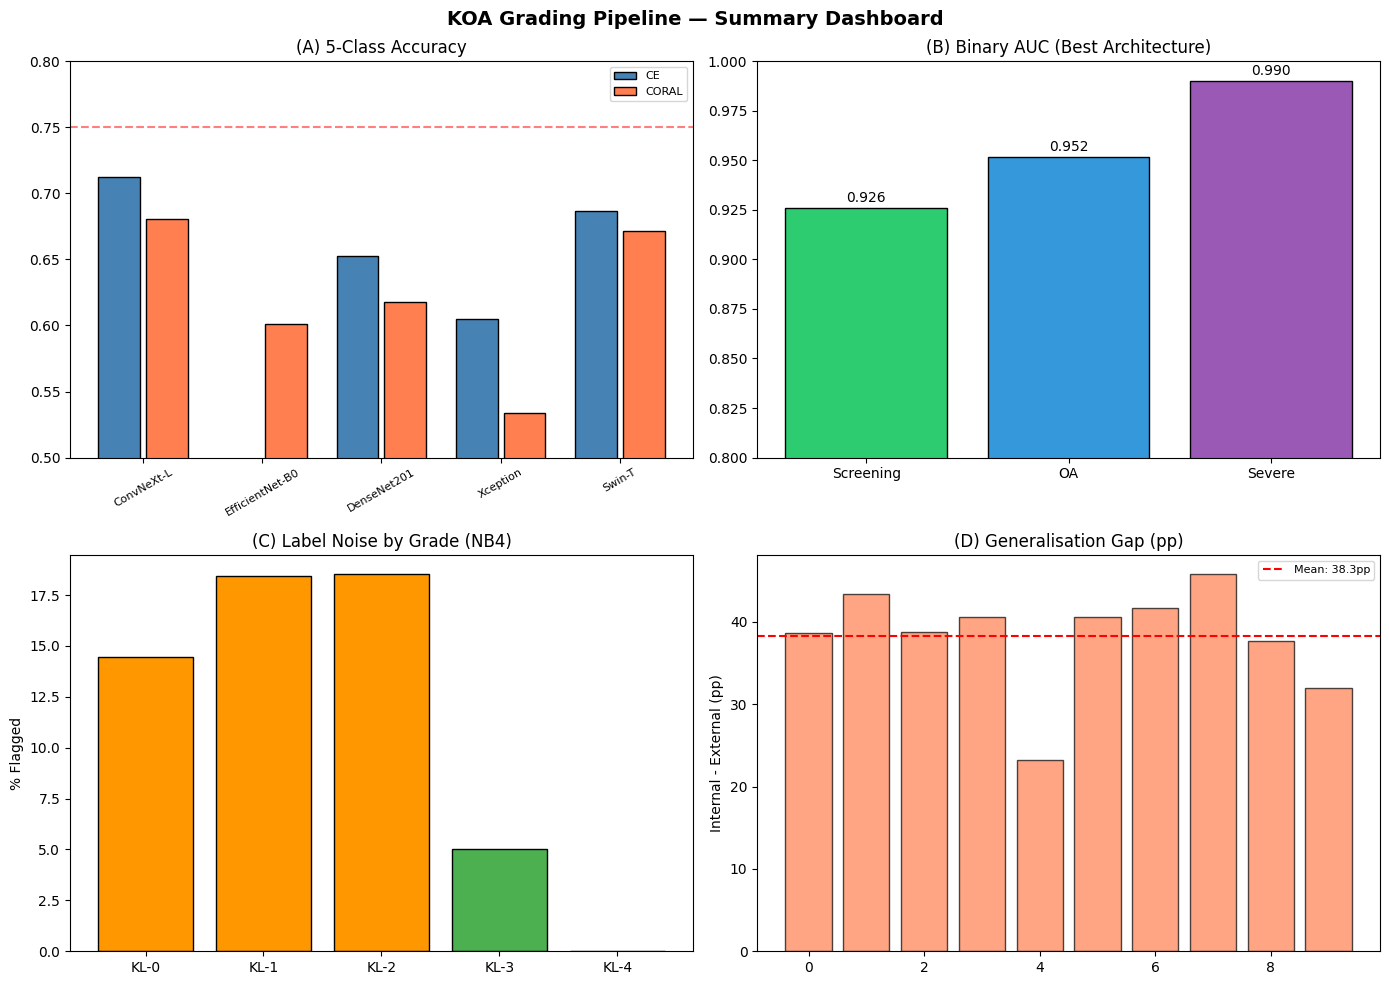

✓ nb6_dashboard.png


In [9]:
# Cell 8 — Dashboard Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

arch_names = list(nb2['results'].keys())
ce_means = [np.mean(nb2['results'][a].get('CE', {}).get('acc', [0])) for a in arch_names]
coral_means = [np.mean(nb2['results'][a].get('CORAL', {}).get('acc', [0])) for a in arch_names]
x = np.arange(len(arch_names))
axes[0,0].bar(x - 0.2, ce_means, 0.35, label='CE', color='steelblue', edgecolor='black')
axes[0,0].bar(x + 0.2, coral_means, 0.35, label='CORAL', color='coral', edgecolor='black')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(arch_names, fontsize=8, rotation=30)
axes[0,0].set_title('(A) 5-Class Accuracy')
axes[0,0].axhline(y=0.75, color='red', linestyle='--', alpha=0.5)
axes[0,0].legend(fontsize=8)
axes[0,0].set_ylim(0.5, 0.8)

bin_tasks = list(nb3.get('tasks', {}).keys())
best_aucs = []
for task in bin_tasks:
    best = max(np.mean(nb3['tasks'][task][a].get('auc', [0])) for a in nb3['tasks'][task])
    best_aucs.append(best)
axes[0,1].bar(bin_tasks, best_aucs, color=['#2ecc71', '#3498db', '#9b59b6'], edgecolor='black')
axes[0,1].set_title('(B) Binary AUC (Best Architecture)')
axes[0,1].set_ylim(0.8, 1.0)
for i, v in enumerate(best_aucs):
    axes[0,1].text(i, v + 0.003, f"{v:.3f}", ha='center', fontsize=10)

nb4_path = KOA_ROOT / 'NB4' / 'nb4_cleanlab.json'
if nb4_path.exists():
    with open(str(nb4_path)) as f:
        nb4 = json.load(f)
    noise_pcts = [nb4['noise_by_grade'][str(i)]['pct'] for i in range(5)]
    colors_noise = ['#4CAF50' if p < 10 else '#FF9800' if p < 25 else '#F44336' for p in noise_pcts]
    axes[1,0].bar([f'KL-{i}' for i in range(5)], noise_pcts, color=colors_noise, edgecolor='black')
    axes[1,0].set_title('(C) Label Noise by Grade (NB4)')
    axes[1,0].set_ylabel('% Flagged')

if gaps:
    axes[1,1].bar(range(len(gaps)), [g * 100 for g in gaps], color='coral', edgecolor='black', alpha=0.7)
    axes[1,1].axhline(y=np.mean(gaps)*100, color='red', linestyle='--',
                       label=f'Mean: {np.mean(gaps)*100:.1f}pp')
    axes[1,1].set_title('(D) Generalisation Gap (pp)')
    axes[1,1].set_ylabel('Internal - External (pp)')
    axes[1,1].legend(fontsize=8)

plt.suptitle('KOA Grading Pipeline — Summary Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(str(NB6_OUT / 'nb6_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb6_dashboard.png")

In [10]:
# Cell 9 — Save Everything
nb6_results = {
    'external_5class': {a: {l: ext_5class[a][l] for l in ext_5class[a]} for a in ext_5class},
    'gen_gap_mean_pp': float(np.mean(gaps) * 100) if gaps else None,
    'gen_gap_std_pp': float(np.std(gaps) * 100) if gaps else None,
    'ceiling_ttest_p': float(p1_one),
}
with open(str(NB6_OUT / 'nb6_results.json'), 'w') as f:
    json.dump(nb6_results, f, indent=2)

for fn in ['nb6_results.json', 'nb6_ext_5class.csv', 'nb6_ext_binary.csv',
           'nb6_gen_gap.png', 'nb6_literature.csv', 'nb6_dashboard.png']:
    print(f"  {'✓' if (NB6_OUT / fn).exists() else '✗'} {fn}")

  ✓ nb6_results.json
  ✓ nb6_ext_5class.csv
  ✓ nb6_ext_binary.csv
  ✓ nb6_gen_gap.png
  ✓ nb6_literature.csv
  ✓ nb6_dashboard.png
